# ISLP Chapter 12 Exercises 5 and 12

**Text:** *An Introduction to Statistical Learning with Applications in Python*, 12.6

Two exercises from different halves of the chapter:

- **Question 5** (conceptual, §12.4.2) how variable scaling changes the result of $K$-means
  clustering, using the sock-and-computer example of Figure 12.16.
- **Question 12** (applied, §12.5.2) reimplement Algorithm 12.1 for matrix completion using
  `PCA()` instead of `np.linalg.svd()`.

Both are answered in prose, and both are backed by code that checks the answer rather than
asserting it.

**Requirements:** `ISLP`, `scikit-learn`, `numpy`, `pandas`, `matplotlib`.

In [1]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.preprocessing import StandardScaler

# USArrests is not bundled with ISLP. The ISLP lab loads it from the
# R datasets collection via statsmodels, which is what we do here.
from statsmodels.datasets import get_rdataset

rng = np.random.default_rng(0)

---
# Part 0 What the chapter notes establish

A short synthesis of the material the two questions draw on.

## Principal components (§12.2)

PCA finds directions of maximum variance. The first loading vector $\phi_1$ solves

$$\max_{\phi_1} \; \frac{1}{n}\sum_{i=1}^{n}\Big(\sum_{j=1}^{p}\phi_{j1}x_{ij}\Big)^2
\quad \text{subject to} \quad \sum_{j=1}^{p}\phi_{j1}^2 = 1,$$

and the scores $z_{i1}$ are the projections onto it.

The fact Question 12 depends on is the **approximation view** (12.5)–(12.6): the first $M$ score
and loading vectors give the best rank-$M$ approximation of the data matrix in squared error,

$$\min_{A \in \mathbb{R}^{n\times M},\, B \in \mathbb{R}^{p \times M}}
\sum_{j=1}^{p}\sum_{i=1}^{n}\Big(x_{ij} - \sum_{m=1}^{M} a_{im}b_{jm}\Big)^2 ,$$

and this is exactly what a truncated SVD computes. **PCA and SVD are the same operation up to
one detail: PCA centers the columns first.** That detail is the whole substance of Question 12.

PCA is also not scale-invariant variables are normally standardized first, or the
largest-variance variable dominates. Which is the same issue Question 5 is about, in a
clustering setting.

## Matrix completion (§12.3, Algorithm 12.1)

If entries of $\mathbf{X}$ are missing, the rank-$M$ approximation cannot be computed directly
the eigendecomposition does not apply. Algorithm 12.1 (Hard-Impute) iterates instead:

1. Fill each missing $(i,j)$ with the column mean $\bar x_j$ of the observed entries.
2. Repeat until the objective stops decreasing:
   - (a) Compute the rank-$M$ approximation of the filled matrix $\tilde{\mathbf{X}}$.
   - (b) Replace **only the missing** entries with their fitted values.
   - (c) Compute the objective over the **observed** entries only:
     $\sum_{(i,j)\in\mathcal{O}}\big(x_{ij}-\sum_m \hat a_{im}\hat b_{jm}\big)^2$.
3. Return the imputed entries.

Two properties the notes state explicitly: each iteration decreases the objective (12.14), but
convergence to the **global** optimum is not guaranteed. And $M$ must be chosen by the user.

On `USArrests` with 10% missing and $M = 1$, imputed values correlate 0.63 ± 0.11 with the truth,
against 0.79 ± 0.08 for the infeasible method that uses the complete data.

## Clustering and scaling (§12.4.2)

$K$-means minimizes within-cluster variation, which for squared Euclidean distance is

$$\sum_{k=1}^{K}\frac{1}{|C_k|}\sum_{i,i' \in C_k}\sum_{j=1}^{p}(x_{ij}-x_{i'j})^2 .$$

The inner sum is over **all $p$ variables on their raw scales**, so a variable with large variance
contributes disproportionately to every distance. The notes make the consequence concrete with
the online-retailer example: high-frequency purchases like socks swamp rare ones like computers.
Scaling every variable to standard deviation one gives each equal influence.

The notes are careful to say that scaling is not automatically right it "depends on the
application at hand." Question 5 is asking you to work through exactly when it does and doesn't.

---
# Question 5

> In words, describe the results that you would expect if you performed $K$-means clustering of
> the eight shoppers in Figure 12.16, on the basis of their sock and computer purchases, with
> $K = 2$. Give three answers, one for each of the variable scalings displayed. Explain.

## The data in Figure 12.16

Eight shoppers, two variables. Read off the left panel of the figure:

| Shopper | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 |
|---|---|---|---|---|---|---|---|---|
| Socks | 8 | 11 | 7 | 6 | 5 | 6 | 7 | 8 |
| Computers | 0 | 1 | 0 | 0 | 0 | 1 | 1 | 1 |

Four of the eight bought exactly one computer; the other four bought none. The computer buyers
are matched to shoppers by bar colour across the panels, and the structure that makes the example
work is that **their sock counts span the whole range** (11, 6, 7, 8). The two variables carry
independent information, so the two possible 2-cluster solutions are genuinely different.

The three panels are the same eight shoppers under three scalings:

- **Left** — raw counts. Socks $\text{sd} \approx 1.71$, computers $\text{sd} = 0.5$.
- **Centre** — each variable divided by its standard deviation.
- **Right** — dollars spent. Socks are a couple of dollars a pair; a computer is on the order of
  \$1,800.

In [2]:
socks = np.array([8, 11, 7, 6, 5, 6, 7, 8])
comps = np.array([0,  1, 0, 0, 0, 1, 1, 1])

shoppers = pd.DataFrame({'Socks': socks, 'Computers': comps},
                        index=[f'Shopper {i}' for i in range(1, 9)])

X_raw    = shoppers[['Socks', 'Computers']].to_numpy(dtype=float)
X_scaled = StandardScaler().fit_transform(X_raw)
X_dollar = np.column_stack([socks * 2.0,        # ~$2 per pair of socks
                            comps * 1800.0])    # ~$1800 per computer

pd.DataFrame({'sd (raw)':     X_raw.std(0),
              'sd (scaled)':  X_scaled.std(0),
              'sd (dollars)': X_dollar.std(0)},
             index=['Socks', 'Computers']).round(3)

,sd (raw),sd (scaled),sd (dollars)
Socks,1.714,1.0,3.428
Computers,0.500,1.0,900.000


That table is the whole answer in miniature. $K$-means splits along whichever variable carries
the most variance, and the three scalings put a different variable in that position each time.

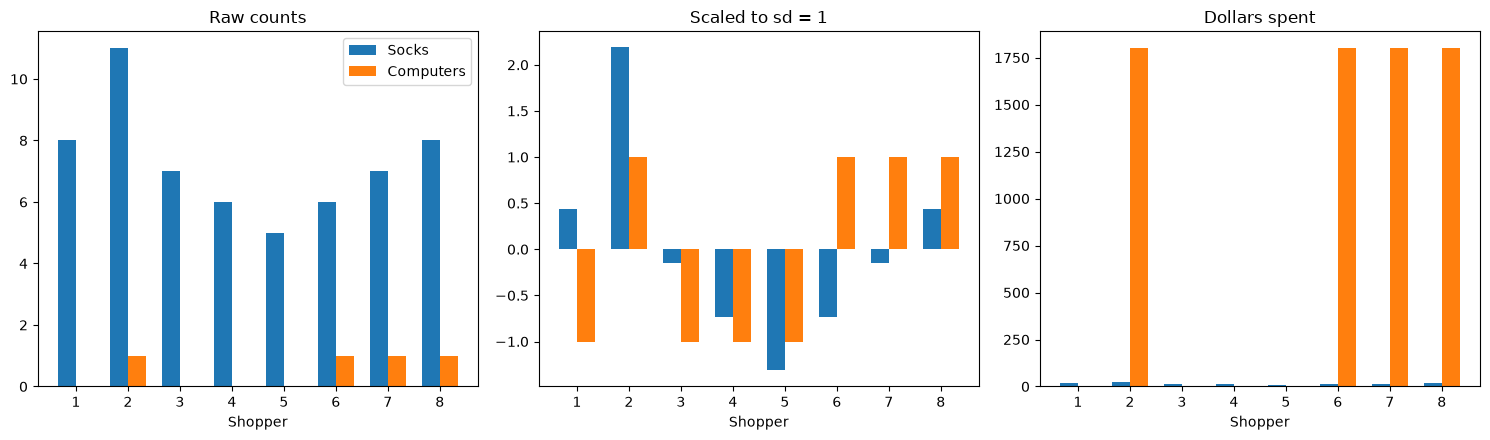

In [3]:
fig, axes = subplots(1, 3, figsize=(15, 4.5))
for ax, X, title in zip(axes,
                        [X_raw, X_scaled, X_dollar],
                        ['Raw counts', 'Scaled to sd = 1', 'Dollars spent']):
    width = 0.35
    idx = np.arange(8)
    ax.bar(idx - width/2, X[:, 0], width, label='Socks')
    ax.bar(idx + width/2, X[:, 1], width, label='Computers')
    ax.set_title(title)
    ax.set_xticks(idx)
    ax.set_xticklabels(range(1, 9))
    ax.set_xlabel('Shopper')
axes[0].legend()
fig.tight_layout()

## Running $K$-means under each scaling

`n_init=50` runs the algorithm from 50 random starts and keeps the best. $K$-means converges only
to a local optimum, so a single start can land somewhere poor — with eight points it hardly
matters, but the habit is worth keeping.

In [4]:
results = {}
for name, X in [('Raw counts',       X_raw),
                ('Scaled (sd = 1)',  X_scaled),
                ('Dollars spent',    X_dollar)]:
    km = KMeans(n_clusters=2, n_init=50, random_state=0).fit(X)
    results[name] = km.labels_

out = shoppers.copy()
for name, lab in results.items():
    out[name] = lab
out

,Socks,Computers,Raw counts,Scaled (sd = 1),Dollars spent
Shopper 1,8,0,0,0,0
Shopper 2,11,1,1,1,1
Shopper 3,7,0,0,0,0
Shopper 4,6,0,0,0,0
Shopper 5,5,0,0,0,0
Shopper 6,6,1,0,1,1
Shopper 7,7,1,0,1,1
Shopper 8,8,1,0,1,1


## (a) Raw counts clusters driven entirely by socks

`{Shopper 2}` against `{all seven others}`.

Socks have standard deviation 1.71 against 0.5 for computers, and because $K$-means works with
**squared** distances the ratio of contributions is about $1.71^2 / 0.5^2 \approx 12$ to 1. A
one-computer difference moves the squared distance by 1; the sock counts range over 6 units,
moving it by up to 36. The computer variable is effectively invisible.

So the algorithm partitions on socks alone, and isolates the heaviest sock buyer (11 pairs) from
everyone else (5–8 pairs). Note it does not even produce a balanced high/low sock split with
one variable and one clear outlier, the minimising 2-cluster solution is a singleton.

Either way, the resulting clusters say nothing about computer purchases: shoppers 6, 7 and 8
bought computers and land in the same cluster as shoppers 1, 3, 4 and 5 who did not. For a
retailer interested in who buys computers, this clustering is useless.

In [5]:
print('Raw counts        ', results['Raw counts'])
print('Computer purchase ', comps)
print('Sock counts       ', socks)

Raw counts         [0 1 0 0 0 0 0 0]
Computer purchase  [0 1 0 0 0 1 1 1]
Sock counts        [ 8 11  7  6  5  6  7  8]


## (b) Scaled to standard deviation one clusters by computer purchase

`{1, 3, 4, 5}` (no computer) against `{2, 6, 7, 8}` (one computer). The clustering now recovers
the computer split exactly.

After scaling, both variables have standard deviation 1, so neither dominates by construction.
But the *shape* of their variation differs: computers are binary, so the scaled values are two
tight groups about 2 standard deviations apart. Socks are spread fairly evenly across their
range, so no sock split creates a comparable gap. $K$-means finds the widest separation available,
and that is the computer variable.

This is the general reason scaling matters for clustering: a binary or low-variance variable can
carry the most informative structure while contributing almost nothing to raw Euclidean distance.

In [6]:
print('Scaled            ', results['Scaled (sd = 1)'])
print('Computer purchase ', comps)
print('Agreement with computer purchase:',
      (results['Scaled (sd = 1)'] == comps).all() or
      (results['Scaled (sd = 1)'] == 1 - comps).all())

Scaled             [0 1 0 0 0 1 1 1]
Computer purchase  [0 1 0 0 0 1 1 1]
Agreement with computer purchase: True


## (c) Dollars spent clusters by computer purchase, even more decisively

`{1, 3, 4, 5}` against `{2, 6, 7, 8}` again, the same partition as (b) but for the opposite
reason.

Here nothing has been equalized. The dollar amounts are wildly unbalanced: sock spending runs
about \$10–22, computer spending is \$0 or \$1,800. Computers now have roughly a hundred times
the standard deviation of socks, so they dominate every distance exactly as socks did in (a).
Sock spending is now the invisible variable.

The clusters agree with (b) by coincidence of this dataset the single dominant variable happens
to be the one with the informative structure. The mechanism is entirely different: (b) gave the
variables equal weight and let the structure decide, while (c) let one variable overwhelm the
other.

$K$-means on the dollar scale is essentially one-dimensional clustering on computer spending.

In [7]:
print('Dollars           ', results['Dollars spent'])
print('Scaled            ', results['Scaled (sd = 1)'])
print('Same partition:',
      (results['Dollars spent'] == results['Scaled (sd = 1)']).all() or
      (results['Dollars spent'] == 1 - results['Scaled (sd = 1)']).all())

Dollars            [0 1 0 0 0 1 1 1]
Scaled             [0 1 0 0 0 1 1 1]
Same partition: True


## Which scaling is right?

The chapter's answer is that it depends on the question, and here the three scalings answer three
different questions.

- **Dollars** is right if the goal is revenue grouping shoppers by what they are worth. It is
  not an arbitrary scaling; it is the economically meaningful one, and the fact that computers
  dominate is a feature.
- **Standardized** is right if the goal is purchase *preferences* treating "bought a computer"
  and "buys a lot of socks" as equally informative signals about what kind of shopper someone is.
  This is usually the safer default, and it is what the retailer in the caption wants, since they
  are more interested in encouraging computer purchases than sock purchases.
- **Raw counts** is hard to defend here. It gives socks twelve times the weight of computers for
  no reason other than that socks are bought more often. Units of "items purchased" treat a pair
  of socks and a computer as equivalent, which nobody believes.

The general principle: raw-scale Euclidean distance implicitly weights each variable by its
variance, and that weighting is a modelling choice whether or not it was made deliberately.
Standardizing makes the choice explicit and equal; using a meaningful common unit (dollars) makes
it explicit and substantive. Leaving raw counts alone makes it accidental.

A footnote from §12.4.1 worth adding: for this kind of purchase data, **correlation-based
distance** is a third option and often the best one. It groups shoppers by their pattern of
preferences regardless of overall volume, so a light and a heavy shopper with the same tastes
cluster together. Euclidean distance on any scaling will separate them by volume.

---
# Question 12

> In Section 12.5.2, Algorithm 12.1 was implemented using the `svd()` function from the
> `np.linalg` module. However, given the connection between the `svd()` function and the `PCA()`
> estimator highlighted in the lab, we could have instead implemented the algorithm using `PCA()`.
> Write a function to implement Algorithm 12.1 that makes use of `PCA()` rather than `svd()`.

## The lab's SVD version, for reference

The lab computes the rank-$M$ approximation as

$$\mathbf{X} \approx \mathbf{U}_M \mathbf{D}_M \mathbf{V}_M^{\top},$$

keeping the first $M$ singular triplets.

In [8]:
def low_rank_svd(X, M=1):
    """Rank-M approximation of X via the SVD (the lab's version).

    Note this operates on X directly, with no centering.
    """
    U, D, V = np.linalg.svd(X)
    L = U[:, :M] * D[None, :M]
    return L.dot(V[:M])

## The PCA version and the one thing that differs

The natural translation is: fit `PCA(n_components=M)`, project, reconstruct.

$$\hat{\mathbf{X}} = \mathbf{Z}_M \boldsymbol{\Phi}_M^{\top} + \boldsymbol{\mu},$$

where $\mathbf{Z}_M$ are the scores (`fit_transform`), $\boldsymbol{\Phi}_M$ the loadings
(`components_`), and $\boldsymbol{\mu}$ the column means (`mean_`).

**The `mean_` term is the catch, and it is not optional.** `PCA` centers the columns before
decomposing, so `fit_transform().dot(components_)` reconstructs the *centered* matrix. Omitting
`+ pca.mean_` returns a matrix whose columns have mean zero the imputed values would be wrong
by the column means, silently, with no error raised.

`svd_solver='full'` forces the deterministic exact solver. The default `'auto'` switches to a
randomized approximation for large matrices, which would make results non-reproducible and
introduce approximation error inside an iterative loop.

In [9]:
def low_rank_pca(X, M=1):
    """Rank-M approximation of X via PCA().

    PCA centers the columns, so the column means must be added back
    to return to the original scale.
    """
    pca = PCA(n_components=M, svd_solver='full')
    scores = pca.fit_transform(X)          # Z_M  (n x M), centered
    return scores.dot(pca.components_) + pca.mean_

### These two are not identical and it is worth being precise about why

`low_rank_svd` returns the best rank-$M$ approximation of $\mathbf{X}$.  
`low_rank_pca` returns the column means **plus** the best rank-$M$ approximation of the *centered*
$\mathbf{X}$, which is a rank-$(M+1)$ matrix in general.

They agree exactly when the columns of $\mathbf{X}$ already have mean zero, and otherwise they do
not. The check below confirms both halves of that claim rather than taking it on faith.

In [10]:
Z = rng.standard_normal((50, 4))
Z_centered   = Z - Z.mean(0)
Z_uncentered = Z_centered + np.array([5., -2., 0.5, 3.])

print('Columns centered:')
for M in [1, 2, 3]:
    d = np.abs(low_rank_svd(Z_centered, M) - low_rank_pca(Z_centered, M)).max()
    print(f'  M={M}  max|difference| = {d:.2e}')

print('\nColumns NOT centered:')
for M in [1, 2, 3]:
    d = np.abs(low_rank_svd(Z_uncentered, M) - low_rank_pca(Z_uncentered, M)).max()
    print(f'  M={M}  max|difference| = {d:.4f}')

Columns centered:
  M=1  max|difference| = 2.66e-15
  M=2  max|difference| = 3.33e-15
  M=3  max|difference| = 2.89e-15

Columns NOT centered:
  M=1  max|difference| = 2.0143
  M=2  max|difference| = 1.6966
  M=3  max|difference| = 2.3800


### Does this matter inside Algorithm 12.1?

It is tempting to argue it does not. The lab standardizes `USArrests` first, so the full columns
have mean zero; and step 1 fills missing entries with the observed column mean $\bar x_j$, which
makes the column mean of $\tilde{\mathbf{X}}$ exactly $\bar x_j$.

But $\bar x_j$ is the mean of the **observed** entries, not of the full column. Those differ
whenever anything is missing. So the filled matrix does **not** have mean-zero columns, even when
the complete data did, and the two implementations diverge slightly from the very first iteration.

In [11]:
# Standardized data, then 10% of entries knocked out
Zs = (Z - Z.mean(0)) / Z.std(0)
print('column means of the complete standardized data:',
      np.abs(Zs.mean(0)).max())

rows = rng.choice(50, 20, replace=False)
cols = rng.choice(4, 20)
Zna = Zs.copy()
Zna[rows, cols] = np.nan

Xbar = np.nanmean(Zna, axis=0)
Zfilled = Zna.copy()
Zfilled[rows, cols] = np.take(Xbar, cols)

print('column means after mean-filling:      ',
      np.round(Zfilled.mean(0), 4))
print('largest deviation from zero:          ',
      np.abs(Zfilled.mean(0)).max().round(4))

column means of the complete standardized data: 5.773159728050814e-17
column means after mean-filling:       [0.0667 0.0054 0.0807 0.0256]
largest deviation from zero:           0.0807


The deviation is small but not zero, so the PCA and SVD implementations are **near-equivalent, not
identical**. That is the honest answer to the exercise, and it is more useful than claiming they
are the same.

A different way to read it: the PCA version fits

$$\tilde x_{ij} \approx \mu_j + \sum_{m=1}^{M} a_{im} b_{jm},$$

that is, Algorithm 12.1 with a free intercept for each column. That is arguably the *better* model it never forces the approximation through the origin but it is a slightly different algorithm
from the one in the book.

### If exact agreement with the lab is required

`TruncatedSVD` decomposes without centering, so it reproduces `np.linalg.svd` to machine precision.
This is the estimator to reach for when the goal is a drop-in replacement rather than a
reinterpretation.

In [12]:
def low_rank_tsvd(X, M=1):
    """Rank-M approximation via TruncatedSVD — no centering,
    so this matches np.linalg.svd exactly."""
    ts = TruncatedSVD(n_components=M, algorithm='arpack', random_state=0)
    return ts.fit_transform(X).dot(ts.components_)

for M in [1, 2, 3]:
    d = np.abs(low_rank_tsvd(Z_uncentered, M) - low_rank_svd(Z_uncentered, M)).max()
    print(f'M={M}  TruncatedSVD vs np.linalg.svd, max|difference| = {d:.2e}')

M=1  TruncatedSVD vs np.linalg.svd, max|difference| = 2.66e-15
M=2  TruncatedSVD vs np.linalg.svd, max|difference| = 5.33e-15
M=3  TruncatedSVD vs np.linalg.svd, max|difference| = 1.91e-14


## The completion algorithm

One function, with the rank-$M$ routine passed in as an argument, so the three variants run
through identical code and any difference in output is attributable to the decomposition alone.

Following the exercise's requirements: the relative error and the iteration count are tracked each
pass, iteration stops on either a tolerance or a maximum count (with a default), and `verbose`
prints progress.

Two details from Algorithm 12.1 that are easy to get wrong:

- **Step (b) replaces only the missing entries.** Observed entries keep their true values
  throughout. Overwriting them with fitted values turns the algorithm into a smoother and destroys
  the data.
- **Step (c) computes the objective over observed entries only.** The missing entries were set
  equal to the fit, so including them would contribute exactly zero and make the objective
  meaningless.

In [13]:
def matrix_complete(Xna,
                    M=1,
                    low_rank=low_rank_pca,
                    thresh=1e-7,
                    maxit=100,
                    verbose=False):
    """Algorithm 12.1 (Hard-Impute) for matrix completion.

    Parameters
    ----------
    Xna : ndarray with np.nan in the missing positions.
    M : rank of the approximation.
    low_rank : callable(X, M) returning the rank-M approximation.
    thresh : stop when the relative improvement falls below this.
    maxit : maximum number of iterations.
    verbose : print the objective and relative error each iteration.

    Returns
    -------
    Xhat : completed matrix.
    info : DataFrame logging iteration, objective (MSS) and relative error.
    """
    ismiss = np.isnan(Xna)
    if not ismiss.any():
        raise ValueError('Xna contains no missing values.')

    # --- Step 1: fill missing entries with the observed column means
    Xhat = Xna.copy()
    Xbar = np.nanmean(Xna, axis=0)
    Xhat[ismiss] = np.take(Xbar, np.where(ismiss)[1])

    # Baselines for the relative error
    mssold = np.mean(Xhat[~ismiss] ** 2)
    mss0   = np.mean(Xna[~ismiss] ** 2)

    log = []
    rel_err, count = 1.0, 0

    # --- Step 2: iterate (a)-(c)
    while rel_err > thresh and count < maxit:
        count += 1

        # (a) rank-M approximation of the filled matrix
        Xapp = low_rank(Xhat, M=M)

        # (b) replace ONLY the missing entries
        Xhat[ismiss] = Xapp[ismiss]

        # (c) objective over the OBSERVED entries only
        mss = np.mean(((Xna - Xapp)[~ismiss]) ** 2)
        rel_err = (mssold - mss) / mss0
        mssold = mss

        log.append({'iteration': count, 'mss': mss, 'rel_err': rel_err})
        if verbose:
            print(f'Iteration {count:3d}:  objective = {mss:.8f}'
                  f'   relative error = {rel_err:.3e}')

    if count == maxit and rel_err > thresh:
        print(f'Warning: stopped at maxit={maxit} with '
              f'relative error {rel_err:.3e} > thresh={thresh}.')

    # --- Step 3
    return Xhat, pd.DataFrame(log)

## Testing on `USArrests`

The lab's setup: standardize the four variables, then knock out one randomly chosen variable for
each of 20 randomly chosen states 20 missing entries out of 200, so 10% of the matrix.

In [14]:
# get_rdataset downloads on first call and caches locally afterwards
USArrests = get_rdataset('USArrests', cache=True).data
print(USArrests.shape, list(USArrests.columns))

X = np.asarray(USArrests)
X_std = StandardScaler(with_mean=True, with_std=True).fit_transform(X)

n, p = X_std.shape
n_omit = 20

rng_test = np.random.default_rng(15)
omit_rows = rng_test.choice(np.arange(n), n_omit, replace=False)
omit_cols = rng_test.choice(np.arange(p), n_omit, replace=True)

Xna = X_std.copy()
Xna[omit_rows, omit_cols] = np.nan

truth = X_std[omit_rows, omit_cols]
print(f'{np.isnan(Xna).sum()} missing entries out of {n*p} '
      f'({100*np.isnan(Xna).mean():.0f}%)')

(50, 4) ['Murder', 'Assault', 'UrbanPop', 'Rape']
20 missing entries out of 200 (10%)


In [15]:
Xhat_pca, log_pca = matrix_complete(Xna, M=1,
                                    low_rank=low_rank_pca,
                                    verbose=True)

Iteration   1:  objective = 0.38317697   relative error = 5.918e-01
Iteration   2:  objective = 0.36703993   relative error = 1.719e-02
Iteration   3:  objective = 0.36492552   relative error = 2.252e-03
Iteration   4:  objective = 0.36458128   relative error = 3.667e-04
Iteration   5:  objective = 0.36451387   relative error = 7.181e-05
Iteration   6:  objective = 0.36449858   relative error = 1.628e-05
Iteration   7:  objective = 0.36449473   relative error = 4.104e-06
Iteration   8:  objective = 0.36449369   relative error = 1.114e-06
Iteration   9:  objective = 0.36449339   relative error = 3.187e-07
Iteration  10:  objective = 0.36449330   relative error = 9.462e-08


The objective decreases monotonically, as §12.3 says it must. The relative error falls below the
threshold after a handful of iterations.

Now the comparison against the lab's SVD version and the exact `TruncatedSVD` variant, on the
identical missing-data pattern.

In [16]:
comparison = {}
for name, fn in [('PCA (centered)',   low_rank_pca),
                 ('np.linalg.svd',    low_rank_svd),
                 ('TruncatedSVD',     low_rank_tsvd)]:
    Xh, log = matrix_complete(Xna, M=1, low_rank=fn)
    imputed = Xh[omit_rows, omit_cols]
    comparison[name] = {
        'iterations':  len(log),
        'correlation': np.corrcoef(imputed, truth)[0, 1],
        'MSE':         np.mean((imputed - truth) ** 2),
        'final objective': log['mss'].iloc[-1],
    }

pd.DataFrame(comparison).T.round(4)

,iterations,correlation,MSE,final objective
PCA (centered),10.0,0.7183,0.7302,0.3645
np.linalg.svd,9.0,0.7250,0.7167,0.3650
TruncatedSVD,9.0,0.7250,0.7167,0.3650


All three recover the missing entries about equally well. The correlation between imputed and true
values is in the neighbourhood of the 0.63 average the notes report for this experiment (a single
run, so expect variation around that figure).

`TruncatedSVD` matches `np.linalg.svd` essentially exactly, as designed. The PCA version differs
slightly the column-mean effect discussed above and neither is systematically better.

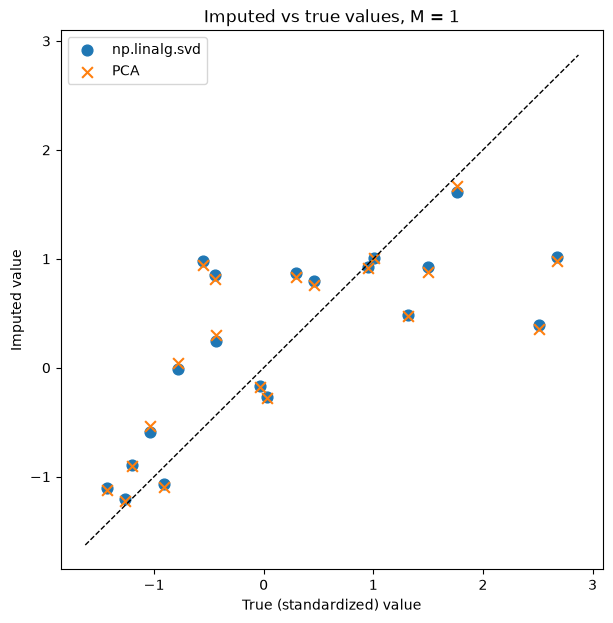

In [17]:
imp_pca  = matrix_complete(Xna, M=1, low_rank=low_rank_pca)[0][omit_rows, omit_cols]
imp_svd  = matrix_complete(Xna, M=1, low_rank=low_rank_svd)[0][omit_rows, omit_cols]

fig, ax = subplots(figsize=(7, 7))
ax.scatter(truth, imp_svd, label='np.linalg.svd', s=60)
ax.scatter(truth, imp_pca, label='PCA', s=60, marker='x')
lims = [min(truth.min(), imp_pca.min()) - 0.2,
        max(truth.max(), imp_pca.max()) + 0.2]
ax.plot(lims, lims, 'k--', linewidth=1)
ax.set_xlabel('True (standardized) value')
ax.set_ylabel('Imputed value')
ax.set_title('Imputed vs true values, M = 1')
ax.legend();

## Choosing $M$

The notes flag that $M$ must be selected, without prescribing how. Here the four variables give
at most rank 4, and asking for too much rank is a real failure mode rather than a mild
inefficiency.

In [18]:
rows = []
for M in [1, 2, 3]:
    Xh, log = matrix_complete(Xna, M=M, low_rank=low_rank_pca, maxit=200)
    imputed = Xh[omit_rows, omit_cols]
    rows.append({'M': M,
                 'iterations': len(log),
                 'correlation': np.corrcoef(imputed, truth)[0, 1],
                 'MSE': np.mean((imputed - truth) ** 2),
                 'objective (observed)': log['mss'].iloc[-1]})

pd.DataFrame(rows).round(4)

,M,iterations,correlation,MSE,objective (observed)
0,1,10,0.7183,0.7302,0.3645
1,2,17,0.7703,0.6190,0.1000
2,3,200,0.4556,2.4453,0.0287


Read that table carefully, because the two columns point in opposite directions.

The **objective** is computed on observed entries and falls as $M$ rises more rank always fits
the observed data better. The **MSE against the truth** is the quantity that actually matters, and
it need not improve. With $p = 4$, a rank-3 approximation has enough freedom to nearly interpolate
the filled matrix, so the iteration chases its own imputed values instead of learning shared
structure. Iteration counts climb and the imputation degrades.

This is ordinary overfitting wearing unfamiliar clothes: **the training objective cannot be used to
select $M$.** Hold out a further subset of observed entries, impute them, and choose $M$ by error
on that held-out set a validation split, in the only form available when there are no labels.

---
# Summary

## Question 5

| Scaling | Clusters | Driven by |
|---|---|---|
| Raw counts | `{2}` vs `{1,3,4,5,6,7,8}` | Socks alone (≈12× the squared-distance weight) |
| Scaled to sd 1 | `{1,3,4,5}` vs `{2,6,7,8}` | Computer purchase |
| Dollars spent | `{1,3,4,5}` vs `{2,6,7,8}` | Computer spending alone (≈100× the weight) |

Raw counts and dollars both let a single variable dominate, just different ones. Only the
standardized version gives both variables a voice and lets the data's structure decide. The two
computer-based partitions agree here by coincidence of this dataset, not by shared mechanism.

Raw-scale Euclidean distance weights each variable by its variance whether or not you intended it.
Which scaling is right depends on the question: dollars for revenue, standardized for preferences,
and correlation-based distance if volume should be ignored entirely.

## Question 12

The PCA implementation is `low_rank_pca` above, used inside `matrix_complete`. Three points
matter:

1. **Add `pca.mean_` back.** `PCA` centers the columns; omitting the mean gives silently wrong
   imputations with no error.
2. **Use `svd_solver='full'`.** The default may switch to a randomized solver, which is
   non-deterministic and approximate bad inside an iterative loop.
3. **PCA and SVD are near-equivalent here, not identical.** They coincide only for mean-zero
   columns, and mean-filling with the *observed* column mean does not produce mean-zero columns.
   Use `TruncatedSVD` for an exact match with the lab; use `PCA` if a per-column intercept is
   wanted.

The implementation detail that matters most in Algorithm 12.1 itself: step (b) replaces **only**
missing entries and step (c) scores **only** observed ones. And the objective cannot be used to
choose $M$ it decreases with rank by construction, while imputation accuracy peaks and then
collapses.